# Customer Churn Prediction - Modeling Phase

This notebook focuses on training and evaluating machine learning models to predict customer churn using the cleaned dataset prepared during the exploratory data analysis phase.

In [12]:
import pandas as pd
df = pd.read_csv('../data/processed/cleaned_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [13]:
x = df.drop('Churn', axis=1)
y = df['Churn']

## Feature and Target Seperation

We seperate the independent variables (features) and the dependent variable (target).

- `x` -> All input features
- `y` -> Target variable (Churn)
The target column **Churn** is removed from features and stored seperately.

In [14]:
categorical_cols = x.select_dtypes(include='object').columns
numerical_cols = x.select_dtypes(include=['int64', 'float64']).columns

## Identifying Categorical and Numerical Columns

Before encoding, we identify:

- **Categorical columns** -> Object type columns (e.g., gender, contract type)
- **Numerical columns** -> int64 and float64 columns

This helps us apply appropriate preprocessing techniques.

In [15]:
x_encoded = pd.get_dummies(x, columns=categorical_cols, drop_first=True)
x_encoded = x_encoded.astype(int)

## Encoding Ctegorical Variables

We apply **One-Hot Encoding** using `pd.get_dummies()` to convert categorical features into numerical format.

- `drop_first=True` is used to avoid the dummy variable trap.
- All columns are converted to integer type for consistency.

Now, the dataset contains only numerical values and is ready for model training.

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42, stratify=y)

## Train-Test Split

The dataset is split into training and testing sets:

- 80% -> Training data
- 20% -> Testing data

We use `stratify=y` to maintain the same class distribution of churn in both training and testing sets.

This ensures balanced evaluation.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

## Feature Scaling
Numerical features are scaled using **StandardScalar**.

Why scaling?
- Some machine learning algorithms (e.g., Logistic Regression, SVM, KNN) are sensitive to feature magnitude.
- Scaling ensures all features contribute equally.

Important:
- The scaler is fitted only on training data.
- The same transformation is applied to test data.

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

## Model Training - Logistic Regression

We train Logistic Regression model for churn prediction.

Logistic Regression is suitable because:
- The target variable (Churn) is binary (0 or 1).
- It prvides probability-based predictions.
- It is interpretable and widely used as a baseline model.

In [8]:
y_pred = model.predict(x_test)

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8038379530916845
[[918 115]
 [161 213]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Model Evaluation

The model performance is evaluated using:
- Accuracy Score
- Confusion Matrix
- Precision
- Recall
- F1-Score

Since customer churn datasets are often imbalanced,
we focus more on Recall and F1-Score rather than only Accuracy.

This helps ensure we correctly identify customers who are likely to churn.

In [11]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8359872858762443


##  ROC-AUC Score

Accuracy alone is not reliable for imbalanced datasets like customer churn.

ROC-AUC (Receiver Operating Characteristic - Area Under Curve):

- Measures how well the model distinguishes between churn and non-churn customers.
- Uses probability predictions instead of class labels.
- AUC ranges from 0 to 1.

Interpretation:
- 0.5 → Model performs like random guessing
- 0.7 - 0.8 → Good model
- 0.8 - 0.9 → Very good model
- 0.9+ → Excellent model

Higher AUC means better separability between classes.

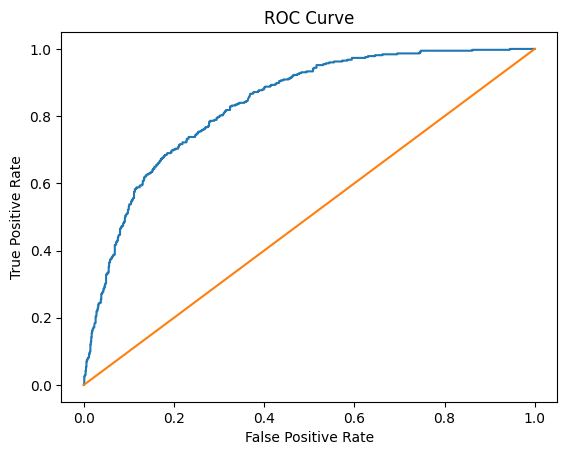

In [22]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()